# Problem Set 10

## Problem: Return of the Galaxy Photometric Redshifts (6 points)

In this exercise, we will return to the galaxy redshifts from problem set 4 and 5, equipped with latest tool: Shapley values. Here is the basic information about the data again.

The file `Problem_Set_4_Redshifts.csv` contains the following data.
* `<BAND>_FLUX`: Fluxes in different bands. This is what will be used for training. Note that the data has been cleaned, and galaxies with missing fluxes have been removed.
* `Z_PHOT`: Ignore this column.
* `Z_SPEC`: These are spectroscopic redshifts $z_\mathrm{spec}$ measured from the Dark Energy Spectroscopic Instrument (DESI).

(a) First, use a random forest (with default parameters) to predict the spectroscopic redshifts based on the fluxes. Show a histogram of the feature importance of each flux, i.e., a bar chart. (You’ve done this task in an earlier problem set. You may reuse your own previous code, but please do not copy the instructor’s posted solution.)

(b) Use `sklearn.neural_network.MLPRegressor` with `max_iter=1000, hidden_layer_sizes=(100, 100, 100)` to predict the spectroscopic redshifts. **Do not forget to scale the input features using `sklearn.preprocessing.StandardScaler`.** This time, measure the importance using the mean absolute Shapley value of each feature accross the data set.

(c) Produce a bar chart that shows both the random forest feature importance and the neural network feature importance as measured by the Shapley values computed in (b). Scale each by the maximum feature importance of each method. How does the neural network's feature importance compare to that of the random forest? Why do the results differ?

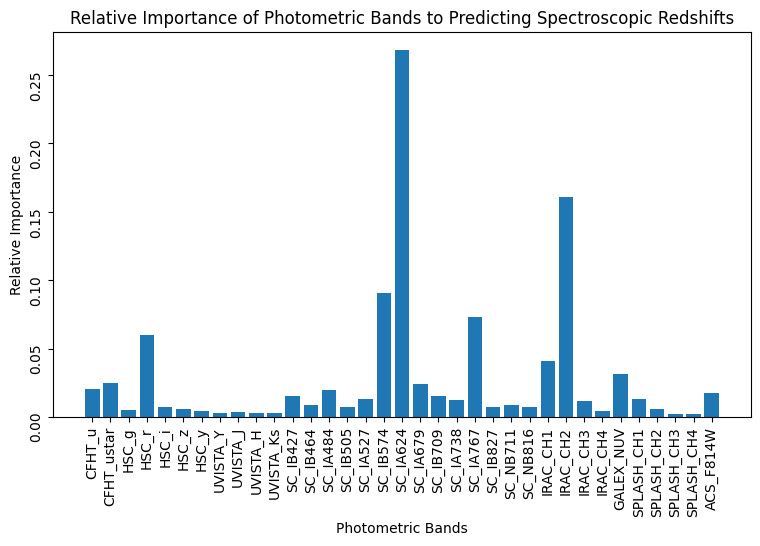

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

df = pd.read_csv("Problem_Set_4_Redshifts.csv")
y = df["Z_SPEC"]
X = df.iloc[:, :35] # all fluxes
rf = RandomForestRegressor().fit(X, y)

fig, ax = plt.subplots(figsize = (9, 5))
ax.tick_params(rotation=90)

# cleaning up string names
headers = []
for header in X.columns:
    new_header = header.replace("_FLUX", "")
    headers.append(new_header)

rf_importance = rf.feature_importances_
plt.bar(headers, rf_importance)
plt.xlabel('Photometric Bands')
plt.ylabel('Relative Importance')
plt.title('Relative Importance of Photometric Bands to Predicting Spectroscopic Redshifts')
plt.show()

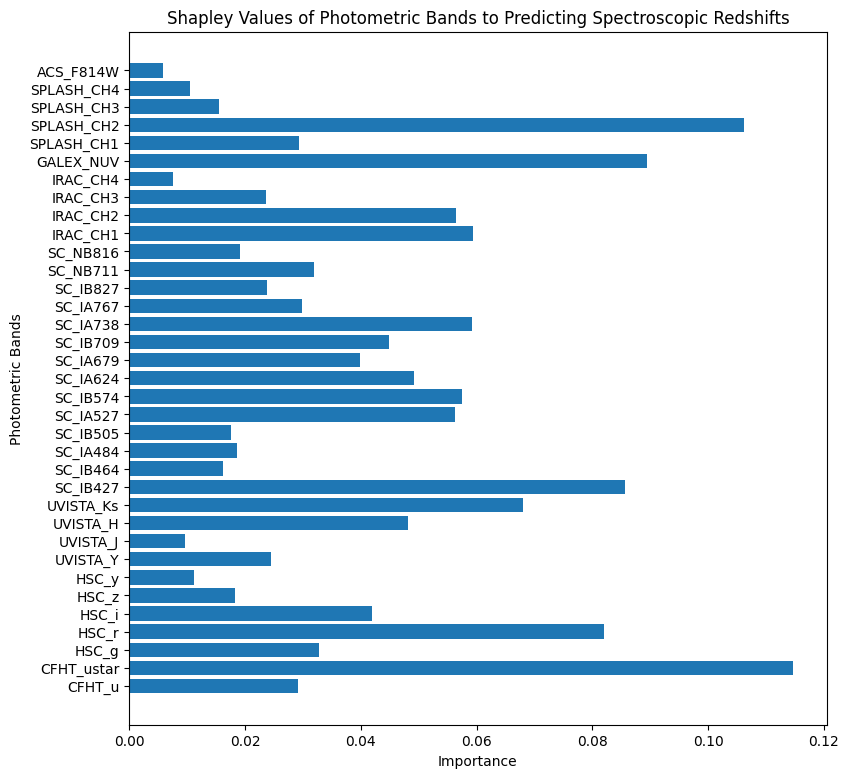

In [34]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

X_scaled = StandardScaler().fit_transform(X)
model = MLPRegressor(max_iter=1000, hidden_layer_sizes=(100, 100, 100)).fit(X_scaled, y)

def compute_shapley_values(X_target, X_bkg, model, n_mc=100):
    """Compute approximate shapley sampling values.

    Parameters
    ----------
    X_target : numpy.ndarray
        Target samples for which to compute Shapley values.
    X_bkg : numpy.ndarray
        Samples used as background in the Monte-Carlo simulation.
    model : object
        Model that has a `predict_proba` function for which we compute the
        Shapley values.
    n : n_mc
        Number of Monte-Carlo simulation. One Monte-Carlo simulations includes
        one random realization of the background and the order for each of the
        target samples.

    Returns
    -------
    shap : numpy.ndarray
        Shapley values. Has the same shape as ``X_target.``

    """
    n_samples, n_feat = X_target.shape
    shap = np.zeros((n_samples, n_feat))

    for k in range(n_mc):
        X = X_bkg[np.random.choice(len(X_bkg), size=len(X_target))]
        perm = np.random.permutation(n_feat)
        pred_old = model.predict(X)
        for feature in perm:
            X[:, feature] = X_target[:, feature]
            pred_new = model.predict(X)
            shap[:, feature] += (pred_new - pred_old) / n_mc
            pred_old = pred_new

    return shap

shap = compute_shapley_values(X_scaled, X_scaled, model, n_mc=300)
shap = np.mean(np.absolute(shap), axis=0)

fig, ax = plt.subplots(figsize = (9, 9))
plt.barh(headers, shap)
plt.ylabel('Photometric Bands')
plt.xlabel('Importance')
plt.title('Shapley Values of Photometric Bands to Predicting Spectroscopic Redshifts')
plt.show()

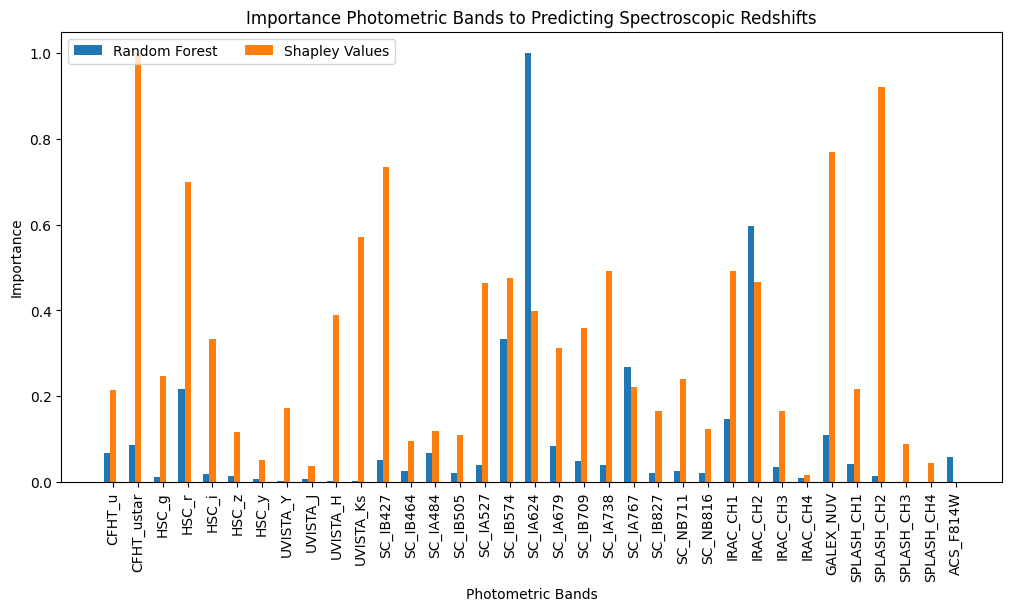

In [36]:
from sklearn.preprocessing import MinMaxScaler

shap_scaled = MinMaxScaler().fit_transform(shap.reshape(-1, 1)).flatten()
rf_importance_scaled = MinMaxScaler().fit_transform(rf_importance.reshape(-1, 1)).flatten()

x = np.arange(len(headers))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained', figsize = (10, 6))

for attribute, measurement in {"Random Forest": rf_importance_scaled, "Shapley Values": shap_scaled}.items():
    offset = width * multiplier
    ax.bar(x + offset, measurement, width, label=attribute)
    multiplier += 1

ax.set_xlabel('Photometric Bands')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', labelrotation=90)
ax.set_title('Importance Photometric Bands to Predicting Spectroscopic Redshifts')
ax.set_xticks(x + width, headers)
ax.legend(loc='upper left', ncols=3)

plt.show()

These results differ because of the way they are calculated. Random forests are based on decision trees, which split the data to reduce the variation, meaning that they often split on the same feature first and falsely inflate one feature's importance over the rest. In contrast, Shapely values iterate over a random selection of all possible permutations, which gives each feature more fair consideration and can provide a more naunced estimate of its importance.